<p> 
    目前的家禽資料量有限，LSTM / xLSTM 模型可能出現過擬合。但這裡的研究目的是探索其可行性，並建立一個方法論上的 baseline。未來只要有更多批次資料，就能更嚴謹地驗證這個模型的泛化能力。
</p>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Sequential
import seaborn as sns
import os
import pickle

In [2]:
# from keras.layers import Dense, LSTM, Dropout
# from keras.optimizers import Adam
# from keras.callbacks import EarlyStopping
from sklearn.linear_model import LinearRegression  # [Additional] 求得回歸方程式

<h3> Definition </h3>

In [3]:
def plot_chick_growth(data, show_legend=False, figsize=(20, 10)):
    """
    繪製每隻雞隻的生長曲線（體重 vs 日齡）

    參數:
        data : DataFrame
            包含 'Chick', 'Age', 'weight' 三個欄位
        show_legend : bool, optional
            是否顯示圖例（預設 False）
        figsize : tuple, optional
            圖片大小，預設 (20, 10)
    """

    # 創建圖形
    fig, ax = plt.subplots(figsize=figsize)

    # 繪製每隻雞隻的體重趨勢
    for chick_id in data['Chick'].unique():
        chick_data = data[data['Chick'] == chick_id]
        ax.plot(chick_data['Age'], chick_data['weight'], marker='o', linestyle='-', label=f'Chick {chick_id}')

    # 設置標題和軸標籤
    ax.set_title('Weight Trends for Each Chick')
    ax.set_xlabel('Age (days)')
    ax.set_ylabel('Weight')

    # 是否顯示圖例
    if show_legend:
        ax.legend()

    plt.show()

In [4]:
def remove_outliers_iqr(data, mode="last", k=1.5):
    """
    用 IQR 法移除離群值（只刪除當天異常點，不刪整隻雞）
    
    參數:
        data: DataFrame，必須包含 ['Chick','Age','weight']
        mode: "last" -> 只檢查最後一天
              "daily" -> 每天都檢查
        k   : IQR 係數 (預設 1.5)
    回傳:
        data_clean: 移除 outlier 後的 DataFrame
    """
    
    if mode == "last":
        check_days = [data['Age'].max()]   # 只檢查最後一天，也就是第21日齡。
    elif mode == "daily":
        check_days = sorted(data['Age'].unique())  # 每天都檢查
    else:
        raise ValueError("mode 必須是 'last' 或 'daily'")
    
    data_clean = data.copy() # 複製資料
    for day in check_days:
        sub = data[data['Age'] == day] # 取出第N天的資料
        # 用IQR法篩選第21天的outlier、計算界線
        Q1, Q3 = sub['weight'].quantile([0.25, 0.75])  
        IQR = Q3 - Q1
        lower_bound, upper_bound = Q1 - k * IQR, Q3 + k * IQR # 預設 k=1.5

        # 標記 outlier
        mask = (data_clean['Age'] == day) & (
            (data_clean['weight'] < lower_bound) | (data_clean['weight'] > upper_bound)
        )
        outliers = data_clean[mask]

        print(f"[Day {day}] Q1={Q1}, Q3={Q3}, IQR={IQR}, "
                  f"下界={lower_bound}, 上界={upper_bound}, "
                  f"異常數={len(outliers)}, "
                  f"發現異常雞隻: {outliers['Chick'].tolist()}")

        # 刪掉這些異常日點
        data_clean.loc[mask, 'weight'] = np.nan # 這裡只刪掉異常日的體重值 → NaN，不會把整隻雞刪掉。
    
    print(f"移除前資料筆數: {len(data)}")
    print(f"移除後資料筆數(含 NaN): {data_clean['weight'].count()} (NaN 已保留，之後可插值補)")
    
    return data_clean


In [5]:
def daily_features(group):
    
    """
    對單日的資料進行聚合，計算統計特徵，用於後續建模或分析。
        包含該群組的統計特徵：
        - min     : 最小值
        - max     : 最大值
        - range   : 變動範圍 (max - min)
        - p25     : 第 25 百分位數（Q1）
        - p75     : 第 75 百分位數（Q3）
        - IQR     : 四分位距 (Q3 - Q1)，衡量數據分散度
        - median  : 中位數
        - std     : 標準差，衡量數據波動
        - mean    : 平均數（這裡同時作為 label，用於監督式學習）
    """
    
    return pd.Series({
        "min": group.min(),
        "max": group.max(),
        "range": group.max() - group.min(),
        "p25": np.percentile(group, 25),
        "p75": np.percentile(group, 75),
        "IQR": np.percentile(group, 75) - np.percentile(group, 25),
        "median": np.median(group),
        "std": group.std(),
        "mean": group.mean()   # 這就是 label
    })

In [6]:
# 讀取csv檔案
data = pd.read_csv('ChickWeight.csv', index_col=0) # 讀取 ChickWeight.csv 檔案
data

,weight,Time,Chick,Diet
1,42,0,1,1
2,51,2,1,1
3,59,4,1,1
4,64,6,1,1
5,76,8,1,1
...,...,...,...,...
574,175,14,50,4
575,205,16,50,4
576,234,18,50,4
577,264,20,50,4


In [7]:
# 假設先暫時忽略Diet餵養雞隻的飼料種類。
data.drop('Diet', axis=1, inplace=True)
# 調整欄位排序
data = data[['Chick', 'Time', 'weight']]
# 更改欄位名稱，Time→Age
data = data.rename(columns={'Time': 'Age'})
data

,Chick,Age,weight
1,1,0,42
2,1,2,51
3,1,4,59
4,1,6,64
5,1,8,76
...,...,...,...
574,50,14,175
575,50,16,205
576,50,18,234
577,50,20,264


In [8]:
# 獲取關於資料表的詳細訊息，有多少Null值。
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 578 entries, 1 to 578
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Chick   578 non-null    int64
 1   Age     578 non-null    int64
 2   weight  578 non-null    int64
dtypes: int64(3)
memory usage: 18.1 KB


<p> 顯示 每筆都有值（沒有缺失值） </p>

In [9]:
data.isnull().sum()

Chick     0
Age       0
weight    0
dtype: int64

<h3> 觀察資料異常值 </h3>

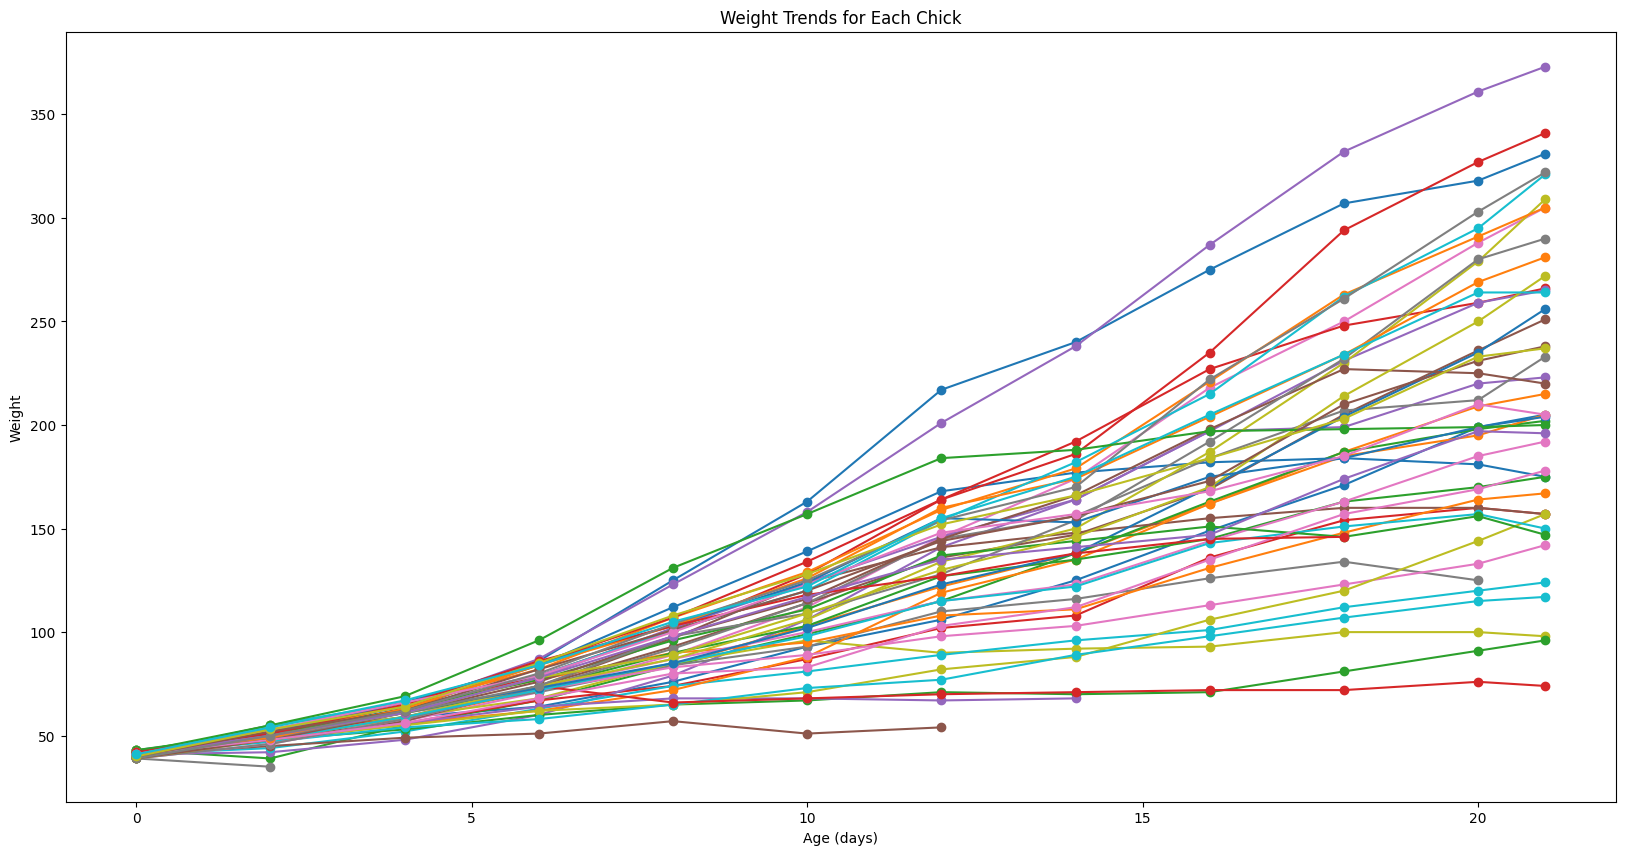

In [10]:
# 所有雞隻的生長曲線
plot_chick_growth(data) # 繪製所有雞隻生長曲線

<p style='color:blue'> ↑ 尚未刪除任何雞隻資料的曲線 </p>

<h4> 篩除掉沒有完整 21 天日齡的雞隻 </h4>
<p> 有些雞隻的曲線在某些天數中斷，代表資料 不完整（少於 21 天的紀錄）。 </p>

In [11]:
complete_chicks = (
    data.groupby("Chick")["Age"]
    .max()                     # 每隻雞的最大日齡
    .loc[lambda x: x >= 21]    # 篩選出有觀察到至少 21 日齡的
    .index
)

# 過濾掉不完整的雞
data_complete = data[data["Chick"].isin(complete_chicks)]

print(f"原本有 {data['Chick'].nunique()} 隻雞")
print(f"完整21天的雞有 {data_complete['Chick'].nunique()} 隻")

原本有 50 隻雞
完整21天的雞有 45 隻


In [12]:
# 找出最大日齡 < 21 的雞（不完整）
incomplete_chicks = (
    data.groupby("Chick")["Age"]
    .max()
    .loc[lambda x: x < 21]   # 最大日齡小於 21
    .index
)

print(f"沒有存活到 21 天的雞共有 {len(incomplete_chicks)} 隻")
print("它們的編號是：", list(incomplete_chicks))

沒有存活到 21 天的雞共有 5 隻
它們的編號是： [8, 15, 16, 18, 44]


In [13]:
# 移除有缺失值的資料 (雞隻編號第8筆、第15筆、第16筆、第18筆、第44筆有缺少數據)
indexes_to_drop = data[data['Chick'].isin([8, 15, 16, 18, 44])].index
data = data.drop(indexes_to_drop) # inplace=True
data

,Chick,Age,weight
1,1,0,42
2,1,2,51
3,1,4,59
4,1,6,64
5,1,8,76
...,...,...,...
574,50,14,175
575,50,16,205
576,50,18,234
577,50,20,264


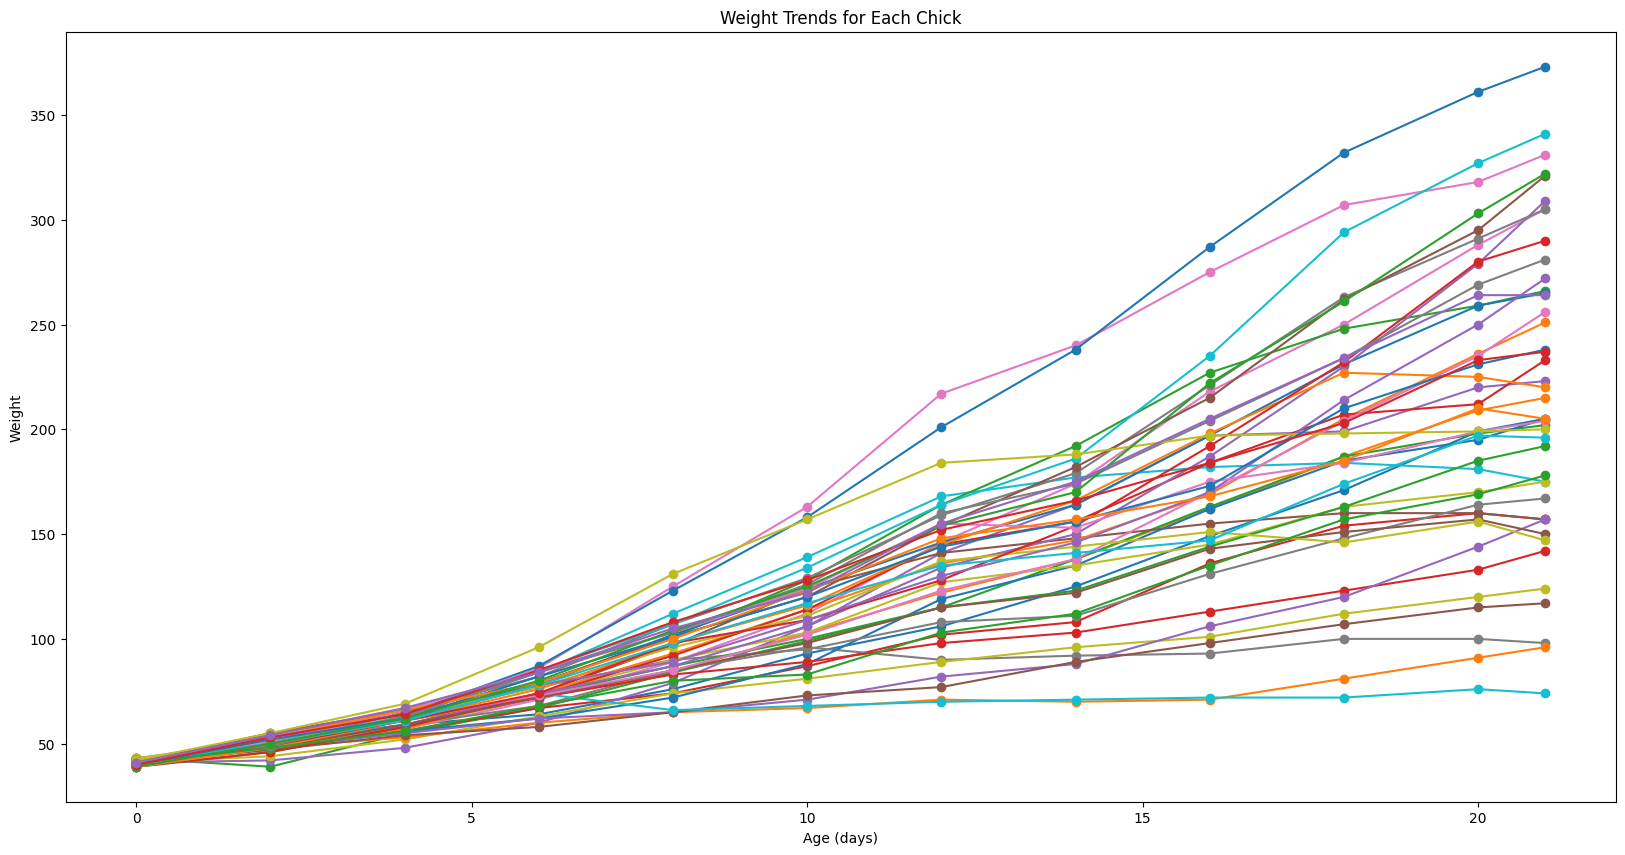

In [14]:
# 只保留有完整21天日齡的雞隻曲線
plot_chick_growth(data) # 繪製所有雞隻生長曲線

<p style='color:blue'> ↑ 刪除沒有完整21天資料的雞隻。維護本次實驗資料的完整性，確保所有在研資料均包含完整的21天生長週期資訊。 </p>

<h4> 用 IQR 法篩選 outlier </h4>

<p> 關於異常值的處理：<br>
離群值，作為潛在異常的指標，其存在有時會歪曲統計分析的結果。在執行資料處理時，必須謹慎地辨識並剔除這些異常數據，以確保分析的準確性和可靠性。 </p>

In [15]:
# 只檢查第21天
data = remove_outliers_iqr(data, mode="last")

[Day 21] Q1=167.0, Q3=266.0, IQR=99.0, 下界=18.5, 上界=414.5, 異常數=0, 發現異常雞隻: []
移除前資料筆數: 540
移除後資料筆數(含 NaN): 540 (NaN 已保留，之後可插值補)


<P style='color:blue'> outliers 空掉，是因為第 21 天的雞隻體重全部都落在 18.5 ~ 414.5 的範圍內，沒有任何一隻超過界線。這代表：用 IQR 法的定義，這批數據「沒有統計學上的離群值」。 </P>

<p style='color:green'>
主要以「第 21 天」檢查為主：<br>
因為研究目的是「驗證方法論」，而最終日齡是 預測標準曲線 的關鍵點。<br>
→ 只要最後的數據乾淨，整體曲線就能合理擬合。
</p>

In [16]:
# 每天都檢查
data = remove_outliers_iqr(data, mode="daily")

[Day 0] Q1=41.0, Q3=42.0, IQR=1.0, 下界=39.5, 上界=43.5, 異常數=6, 發現異常雞隻: [27, 28, 29, 33, 36, 48]
[Day 2] Q1=48.0, Q3=51.0, IQR=3.0, 下界=43.5, 上界=55.5, 異常數=2, 發現異常雞隻: [3, 5]
[Day 4] Q1=58.0, Q3=63.0, IQR=5.0, 下界=50.5, 上界=70.5, 異常數=1, 發現異常雞隻: [5]
[Day 6] Q1=71.0, Q3=80.0, IQR=9.0, 下界=57.5, 上界=93.5, 異常數=1, 發現異常雞隻: [43]
[Day 8] Q1=84.0, Q3=102.0, IQR=18.0, 下界=57.0, 上界=129.0, 異常數=1, 發現異常雞隻: [43]
[Day 10] Q1=96.0, Q3=124.0, IQR=28.0, 下界=54.0, 上界=166.0, 異常數=0, 發現異常雞隻: []
[Day 12] Q1=115.0, Q3=154.0, IQR=39.0, 下界=56.5, 上界=212.5, 異常數=1, 發現異常雞隻: [21]
[Day 14] Q1=123.0, Q3=170.0, IQR=47.0, 下界=52.5, 上界=240.5, 異常數=0, 發現異常雞隻: []
[Day 16] Q1=144.0, Q3=197.0, IQR=53.0, 下界=64.5, 上界=276.5, 異常數=1, 發現異常雞隻: [35]
[Day 18] Q1=157.0, Q3=231.0, IQR=74.0, 下界=46.0, 上界=342.0, 異常數=0, 發現異常雞隻: []
[Day 20] Q1=164.0, Q3=259.0, IQR=95.0, 下界=21.5, 上界=401.5, 異常數=0, 發現異常雞隻: []
[Day 21] Q1=167.0, Q3=266.0, IQR=99.0, 下界=18.5, 上界=414.5, 異常數=0, 發現異常雞隻: []
移除前資料筆數: 540
移除後資料筆數(含 NaN): 527 (NaN 已保留，之後可插值補)


<ol> 每天都檢查 (全序列 outlier 清理)
   <li>定位是 探索性研究 (Exploratory Research)</li>
    <li>然後再用 線性插值 補回缺口，保證序列完整。</li>
</ol>

<ol> 不建議用「100g」這種人為閥值🚫，原因有三個：
    <li> 缺乏科學依據：100g 是主觀選的，沒有統計或生物學標準支撐。口委如果問「為什麼不是 90g 或 110g？」會很難回答。 </li>
    <li> 不具泛用性：不同批次、品種、飼養環境，21 日齡的平均體重可能不同，一個固定值不一定適合所有情況。 </li>
    <li> 容易被質疑資料操作：用固定數字刪資料，會被懷疑「你是不是為了讓結果好看才這樣做？」 </li>
</ol>

<p> 推薦的做法：用 統計規則（如 1.5×IQR） → 論文可以寫「依據 Tukey 箱型圖法則」。</p>

<h3> 補插值（linear interpolation) </h3>
建立完整日齡範圍 & 補值，變成每天都有雞隻的體重資料。

In [17]:
# 建立 0–21 天的完整日齡範圍
full_range = pd.DataFrame([
    (chick, age)
    for chick in data['Chick'].unique()
    for age in range(0, 22)  # 0~21天
], columns=['Chick','Age'])


# merge回原始資料，讓缺的日齡變成 NaN
data_full = pd.merge(full_range, data, on=['Chick','Age'], how='left')

# 線性插值，對每隻雞分開處理
data_full['weight'] = data_full.groupby('Chick')['weight'].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both') # 對缺失值補線性插值（linear interpolation），limit_direction='both'：確保頭尾 NaN 也能補。
)

data = data_full # 確保變數名稱保持一致

print(data['Chick'].unique())
# print(data.groupby("Chick")["Age"].count()) # 每隻雞應該都會有 22 筆 (0–21天)。
data

[ 1  2  3  4  5  6  7  9 10 11 12 13 14 17 19 20 21 22 23 24 25 26 27 28
 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 45 46 47 48 49 50]


,Chick,Age,weight
0,1,0,42.0
1,1,1,46.5
2,1,2,51.0
3,1,3,55.0
4,1,4,59.0
...,...,...,...
985,50,17,219.5
986,50,18,234.0
987,50,19,249.0
988,50,20,264.0


<h3> 視覺化圖表 </h3>

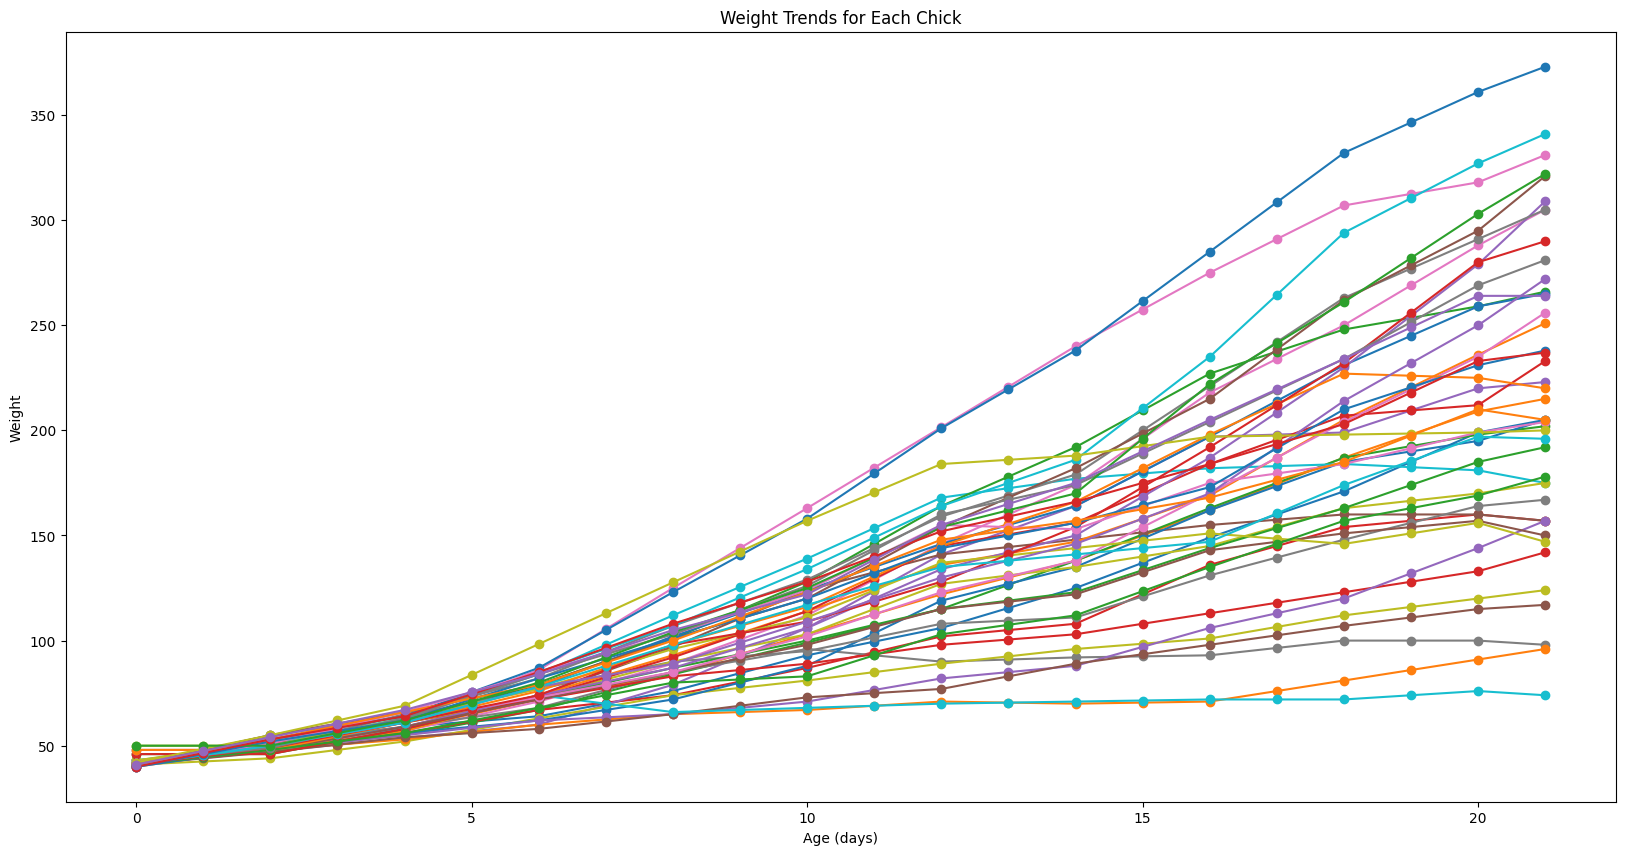

In [18]:
# 只保留有完整21天日齡的雞隻曲線
plot_chick_growth(data) # 繪製所有雞隻生長曲線

回歸線方程式: y = 8.87x + 27.58


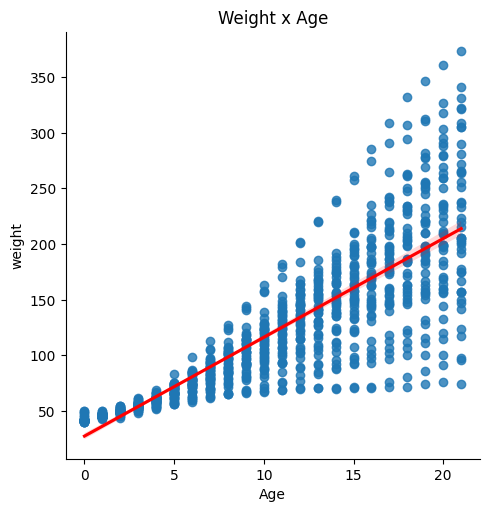

In [19]:
# 若用 回歸線方程式 觀察曲線
sns.lmplot(data=data, x='Age', y='weight', line_kws={'color': 'red'})
plt.title('Weight x Age')

# 将数据转换为适合 sklearn 的格式
Age = np.array(data['Age']).reshape(-1, 1)  # 特征变量，需要是二维数组
weight = np.array(data['weight'])  # 目标变量
# 创建线性回归模型实例
model = LinearRegression()
# 拟合模型
model.fit(Age, weight)
# 获取斜率（slope）和截距（intercept）
slope = model.coef_[0]
intercept = model.intercept_
print(f"回歸線方程式: y = {slope:.2f}x + {intercept:.2f}")

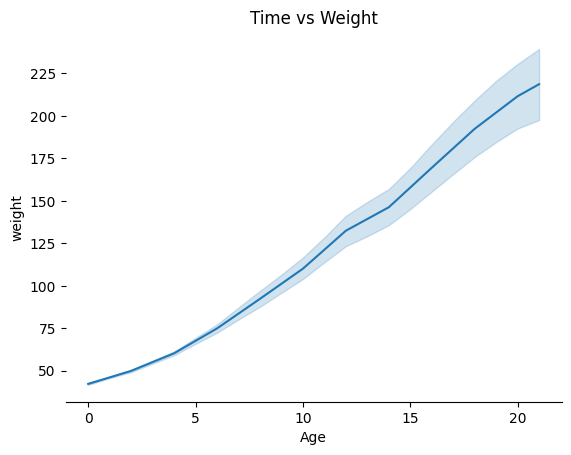

In [20]:
# 繪製lineplot
sns.lineplot(data=data, x="Age", y="weight")
sns.despine(left=True) # 設定边框线，使图表更加简洁美观。
plt.title("Time vs Weight")
plt.show()

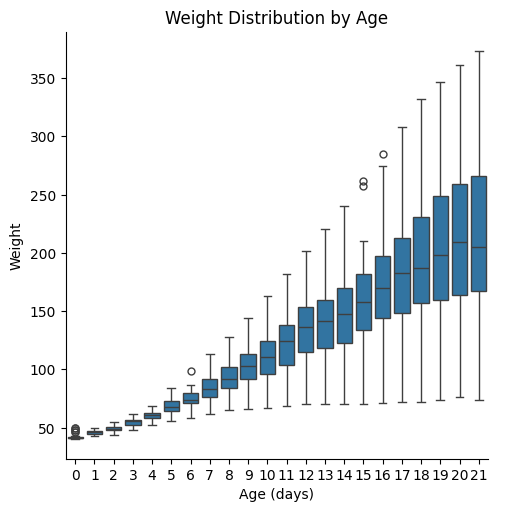

In [21]:
# catplot
sns.catplot(data=data, x="Age", y="weight", kind='box')
plt.title("Weight Distribution by Age")
plt.xlabel("Age (days)")
plt.ylabel("Weight")
plt.show()

<h3> 每日聚合 → 統計特徵 </h3>

In [22]:
# Step 2. 每日聚合 → 統計特徵
# 按照日齡把資料分組，只對 weight 欄位做計算，對每組（同一天所有雞的體重）呼叫你定義的 daily_features，算出最小值、最大值、IQR、中位數、平均數等統計特徵，最後再把 Age 從 groupby 索引還原成一般欄位，方便後續分析。
daily_stats = data.groupby("Age")["weight"].apply(daily_features) # .reset_index()
daily_stats = daily_stats.unstack()  # 把 level_1 拉到 columns
daily_stats

,min,max,range,p25,p75,IQR,median,std,mean
Age,,,,,,,,,
0,40.0,50.000000,10.000000,41.0,42.0,1.0,41.0,2.480836,42.266667
1,42.5,50.000000,7.500000,45.0,47.0,2.0,46.0,1.548278,46.092593
2,44.0,55.000000,11.000000,48.0,51.0,3.0,49.0,2.467113,49.918519
3,48.0,62.000000,14.000000,52.5,57.0,4.5,55.5,3.029401,55.100000
4,52.0,69.000000,17.000000,58.0,63.0,5.0,61.0,3.987326,60.281481
5,56.0,83.666667,27.666667,64.0,72.5,8.5,67.5,6.099905,67.600000
6,58.0,98.333333,40.333333,71.0,80.0,9.0,74.0,8.516222,74.918519
7,61.5,113.000000,51.500000,76.5,91.5,15.0,83.5,11.734952,83.633333
8,65.0,127.666667,62.666667,84.0,102.0,18.0,92.0,15.408570,92.348148


<h3> Scaler 標準化 </h3>

In [23]:
# 存檔
daily_stats.to_csv("kaggle_chicks_daily_features.csv", index=True)
print("已輸出 kaggle_chicks_daily_features.csv")

已輸出 kaggle_chicks_daily_features.csv


In [24]:
# 複製一份避免覆蓋原始
df_scaled = daily_stats.copy()

<h4> 建立 scaler 並 fit_transform 特徵欄位 </h4>

In [25]:
# === Step 1. 指定目標與特徵欄位  ===
feature_cols = ["min","max","range","p25","p75","IQR","median","std"]
target_col = "mean"

In [26]:
# === Step 2. 先把 DataFrame 裡的數據直接標準化 (Scaling) ===
feature_scaler  = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。
target_scaler  = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。

# 特徵 scaling
df_scaled[feature_cols] = feature_scaler.fit_transform(df_scaled[feature_cols])
# 目標 scaling
df_scaled[target_col] = target_scaler.fit_transform(df_scaled[[target_col]])

<h4> Save Dataset & 拆分資料 </h4>

In [27]:
# 存檔，存成 CSV，方便之後重複使用或 Debug。
df_scaled.to_csv("kaggle_chicks_daily_features(Normalized).csv", index=True)
print("已輸出 kaggle_chicks_daily_features(Normalized)")

已輸出 kaggle_chicks_daily_features(Normalized)


In [28]:
# === Step 3.再拆成 X（特徵） 和 y（目標）===
X = df_scaled[feature_cols].values
y = df_scaled[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (22, 8)
y shape: (22,)


In [29]:
# === Step 4. Train/Test Split (前 70% 為 train，後 30% 為 test) ===
split_index = int(len(df_scaled) * 0.7)

X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)


Train shape: (15, 8) (15,)
Test  shape: (7, 8) (7,)


In [30]:
# === Step 5. 儲存成 pkl 檔案 ===
data_dic = {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
    "feature_scaler": feature_scaler,  # 存下來方便 inverse_transform
    "target_scaler": target_scaler
}

In [31]:
folder_name = "70%Training_30%Testing"
os.makedirs(folder_name, exist_ok=True)

for key, value in data_dic.items():
    file_path = os.path.join(folder_name, f"{key}.pkl")
    with open(file_path, "wb") as f:
        pickle.dump(value, f)
    print(f"已儲存：{file_path}")

已儲存：70%Training_30%Testing\X_train.pkl
已儲存：70%Training_30%Testing\y_train.pkl
已儲存：70%Training_30%Testing\X_test.pkl
已儲存：70%Training_30%Testing\y_test.pkl
已儲存：70%Training_30%Testing\feature_scaler.pkl
已儲存：70%Training_30%Testing\target_scaler.pkl
